# Cross-Version Benchmark Leaderboards

This notebook builds leaderboards from benchmark outputs in `benchmarking/benchmarks/*/results/baseline` and `v10+`.

**v13 is excluded.** Captioning failures during indexing (empty-caption DLQ force-inserts and abandoned items) left collections incomplete or degraded and inflated retrieval scores. The run remains under `results/v13/` for the record; v14 is the first comparable Milvus dual-index / CLIP DFN run after those failures were addressed.

When present, `baseline` is the CLIP-only ablation (no caption generation, keyword search, or hybrid search).

It includes:
- Primary leaderboard (`MRR`, `Success@25`)
- Primary + Diversity leaderboard (adds `Diversity@25`)

`Success@25` is computed from the `hit` column mean.


A separate **Primary leaderboard (with ablation studies)** section includes `ablation_*` runs alongside baseline and `v10+`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

# Repo root from benchmarking/benchmarks/<BENCHMARK>/results
_repo_root = Path.cwd().parents[3]
sys.path.insert(0, str(_repo_root))

base_path = (_repo_root / "benchmarking" / "benchmarks").resolve()

from benchmarking.helpers.plot import (
    render_single_benchmark_leaderboard,
    DEFAULT_PRIMARY_WEIGHTS,
    DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS,
)

In [2]:
# Configuration
# This notebook ranks only the benchmark folder it lives in.
# Expected cwd when running this notebook: benchmarking/benchmarks/<BENCHMARK>/results
current_benchmark = Path.cwd().parents[0].name if Path.cwd().name == "results" else Path.cwd().name
min_version = 10

# Default metric weights are equal, but can be customized.
primary_metric_weights = dict(DEFAULT_PRIMARY_WEIGHTS)
primary_plus_diversity_metric_weights = dict(DEFAULT_PRIMARY_PLUS_DIVERSITY_WEIGHTS)

print("Base path:", base_path)
print("Benchmark selected:", current_benchmark)
print("Primary weights:", primary_metric_weights)
print("Primary + Diversity weights:", primary_plus_diversity_metric_weights)

Base path: /home/runner/work/sage-nrp-image-search/sage-nrp-image-search/benchmarking/benchmarks
Benchmark selected: Sagebench
Primary weights: {'MRR': 0.5, 'Success@25': 0.5}
Primary + Diversity weights: {'MRR': 0.3333333333333333, 'Success@25': 0.3333333333333333, 'Diversity@25': 0.3333333333333333}


## Primary Leaderboard

Ranking uses weighted composite of:
- `MRR`
- `Success@25`


Sagebench (Primary):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Sagebench,v16,120,0.203208,0.716667,0.030667,0.313149,0.659306,0.212726,0.459937,1
1,Sagebench,v15,120,0.229657,0.641667,0.027000,0.321936,0.591944,0.226040,0.435662,2
2,Sagebench,v14,120,0.193118,0.666667,0.028333,0.294864,0.614583,0.228713,0.429892,3
3,Sagebench,v11,120,0.112226,0.625000,0.026333,0.220402,0.567222,0.201079,0.368613,4
4,Sagebench,v12,120,0.121780,0.541667,0.022667,0.211107,0.503333,0.207045,0.331723,5
5,Sagebench,v10,120,0.100567,0.533333,0.022667,0.188671,0.482222,0.204302,0.316950,6
6,Sagebench,baseline,120,0.085341,0.350000,0.014000,0.113845,0.303750,0.149703,0.217671,7


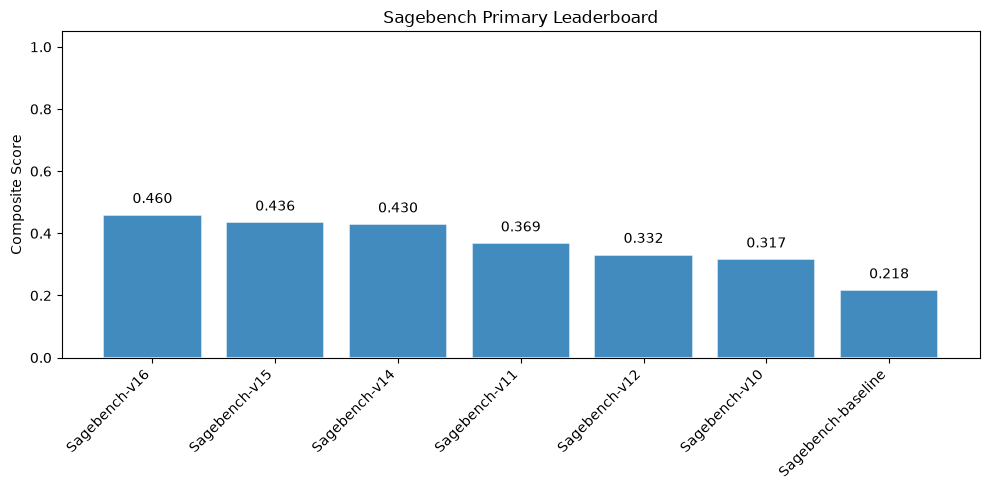

In [3]:
primary_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)

## Primary + Diversity Leaderboard

Adds `Diversity@25` to the weighted score.


Sagebench (Primary + Diversity):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Sagebench,v16,120,0.203208,0.716667,0.030667,0.313149,0.659306,0.212726,0.377533,1
1,Sagebench,v15,120,0.229657,0.641667,0.027000,0.321936,0.591944,0.226040,0.365788,2
2,Sagebench,v14,120,0.193118,0.666667,0.028333,0.294864,0.614583,0.228713,0.362833,3
3,Sagebench,v11,120,0.112226,0.625000,0.026333,0.220402,0.567222,0.201079,0.312768,4
4,Sagebench,v12,120,0.121780,0.541667,0.022667,0.211107,0.503333,0.207045,0.290164,5
5,Sagebench,v10,120,0.100567,0.533333,0.022667,0.188671,0.482222,0.204302,0.279401,6
6,Sagebench,baseline,120,0.085341,0.350000,0.014000,0.113845,0.303750,0.149703,0.195015,7


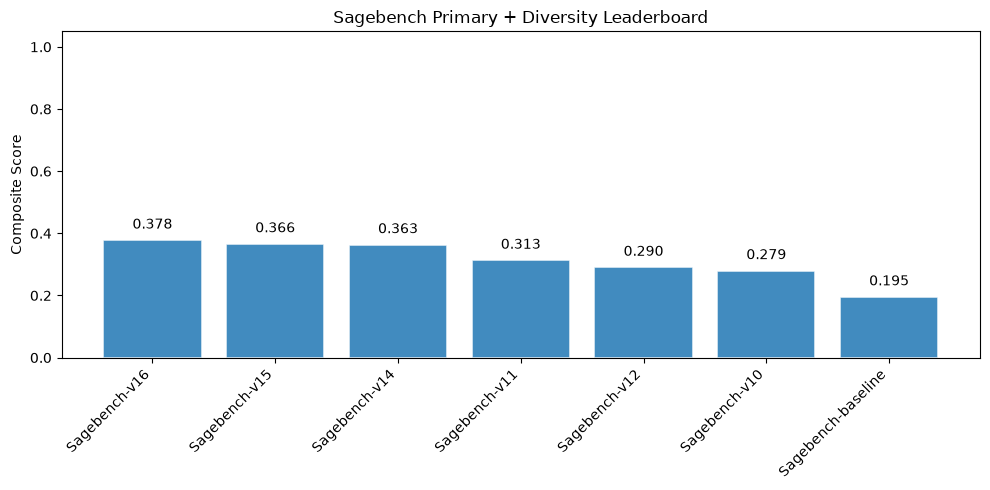

In [4]:
primary_plus_diversity_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    mode="primary_plus_diversity",
    metric_weights=primary_plus_diversity_metric_weights,
    display_fn=display,
)

## Primary Leaderboard (with Ablation Studies)

Same weighted composite as the primary leaderboard (`MRR`, `Success@25`), but also includes `ablation_*` result folders when present.



Sagebench (Primary (with Ablation Studies)):


,benchmark,system_version,query_count,MRR,Success@25,Precision@25,NDCG@25,Recall@25,Diversity@25,composite_score,rank_within_benchmark
0,Sagebench,v16,120,0.203208,0.716667,0.030667,0.313149,0.659306,0.212726,0.459937,1
1,Sagebench,v15,120,0.229657,0.641667,0.027000,0.321936,0.591944,0.226040,0.435662,2
2,Sagebench,v14,120,0.193118,0.666667,0.028333,0.294864,0.614583,0.228713,0.429892,3
3,Sagebench,ablation_cap_only,120,0.153490,0.600000,0.026000,0.246744,0.566944,0.325186,0.376745,4
4,Sagebench,v11,120,0.112226,0.625000,0.026333,0.220402,0.567222,0.201079,0.368613,5
5,Sagebench,ablation_img_only,120,0.156857,0.550000,0.025000,0.184419,0.501944,0.160513,0.353429,6
6,Sagebench,v12,120,0.121780,0.541667,0.022667,0.211107,0.503333,0.207045,0.331723,7
7,Sagebench,ablation_vec_only,120,0.132251,0.508333,0.022333,0.211588,0.479722,0.153834,0.320292,8
8,Sagebench,v10,120,0.100567,0.533333,0.022667,0.188671,0.482222,0.204302,0.316950,9
9,Sagebench,baseline,120,0.085341,0.350000,0.014000,0.113845,0.303750,0.149703,0.217671,10


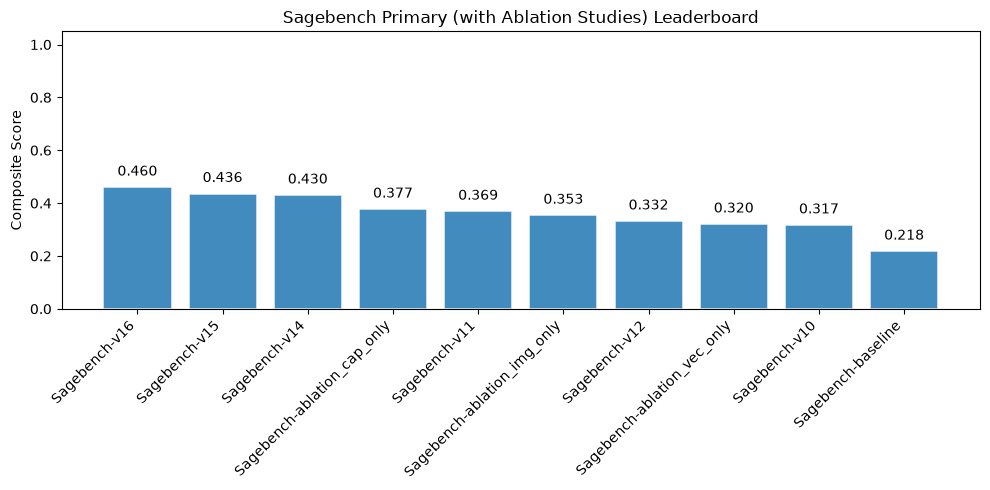

In [5]:
primary_ablation_df = render_single_benchmark_leaderboard(
    base_path=base_path,
    benchmark=current_benchmark,
    min_version=min_version,
    include_ablations=True,
    mode="primary",
    metric_weights=primary_metric_weights,
    display_fn=display,
)